In [51]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline 

In [52]:
from sklearn.datasets import load_iris

In [53]:
iris = load_iris()
df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['target'] = iris.target

In [54]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [55]:
X = df.drop('target',axis=1)
y = df['target']

In [56]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [57]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [60]:
from sklearn.neighbors import KNeighborsClassifier

In [61]:
kmean = KNeighborsClassifier(n_neighbors=5,algorithm='auto')

In [62]:
kmean.fit(X_train,y_train)

KNeighborsClassifier()

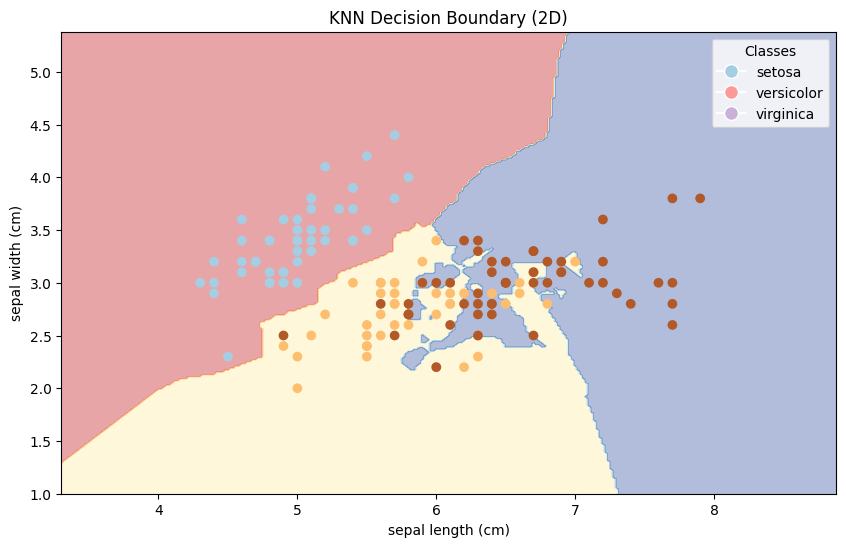

In [86]:
# Use only the first two features
X = df.iloc[:, :2].values
y = df["target"].values

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# Create meshgrid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)

import matplotlib.lines as mlines

# Plot the data points with colors based on their labels
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)

# Manually create legend handles for each class
handles = []
for i in range(len(iris.target_names)):
    handle = mlines.Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.Paired(i / len(iris.target_names)), markersize=10, label=iris.target_names[i])
    handles.append(handle)

# Add the legend to the plot
plt.legend(handles=handles, title="Classes")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("KNN Decision Boundary (2D)")
plt.show()


In [63]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [64]:
y_pred = kmean.predict(X_test)

In [65]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

1.0
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


## Hyperparameter Tuning 

In [69]:
params = {'n_neighbors' : [1,2,3,4,5,6,7,8,9,10],
              'algorithm':['ball_tree','kd_tree','brute']}


In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
gcv = GridSearchCV(estimator=kmean,param_grid=params,cv = 5,scoring='accuracy')

In [72]:
gcv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy')

In [73]:
gcv.best_estimator_

KNeighborsClassifier(algorithm='ball_tree', n_neighbors=4)

In [74]:
y_pred1 = gcv.predict(X_test)

In [87]:
print(classification_report(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

1.0
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
